# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Rizky Prayogi Reksomulyo
- Email: rizki45645@gmail.com
- Id Dicoding: ogiii

## Business Understanding

Jaya Jaya Institut adalah institusi pendidikan tinggi yang telah berdiri sejak tahun 2000. Meskipun telah mencetak banyak lulusan berprestasi, institusi ini menghadapi masalah tingginya angka mahasiswa yang putus kuliah (*dropout*). Tingginya angka *dropout* ini berdampak besar pada reputasi institusi dan efisiensi operasional pendidikan.

### Permasalahan Bisnis

Beberapa permasalahan utama yang dihadapi oleh institusi:

1. Faktor-faktor apa saja yang paling signifikan mempengaruhi keputusan seorang mahasiswa untuk *dropout*?
2. Bagaimana cara mengidentifikasi atau memprediksi mahasiswa yang berisiko tinggi untuk *dropout* sejak dini?
3. Bagaimana memonitor performa mahasiswa dan tren *dropout* secara interaktif melalui *dashboard*?

### Cakupan Proyek

1. **Data Wrangling & EDA**: Memahami karakteristik dataset, membersihkan data, memfilter status mahasiswa yang masih aktif (*Enrolled*), dan menganalisis hubungan visual antara berbagai metrik terhadap status kelulusan.
2. **Data Preprocessing**: Pemisahan fitur dan target, pembagian data menjadi *training* dan *testing set*, serta penanganan *class imbalance* dengan SMOTE.
3. **Machine Learning Modeling**: Membangun dan mengevaluasi model klasifikasi menggunakan **Random Forest** dan **Gradient Boosting**.
4. **Deployment**: Menyimpan model terbaik dan membuat aplikasi prediksi interaktif menggunakan Streamlit.
5. **Business Dashboard**: Menggunakan Looker Studio untuk memonitor performa mahasiswa dan metrik *dropout* secara interaktif.

## Persiapan

### Menyiapkan library yang dibutuhkan

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import joblib
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder



### Menyiapkan data yang akan digunakan


In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/students_performance/data.csv", delimiter=';')
df.head()


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Tahap **Data Understanding** bertujuan untuk memahami karakteristik dataset yang akan digunakan. Pada tahap ini, kita akan:

1. **Memeriksa informasi umum dataset**: Menampilkan tipe data, jumlah entri, dan jumlah kolom
2. **Melihat statistik deskriptif**: Menampilkan ringkasan statistik (mean, std, min, max, quartiles) untuk setiap kolom numerik
3. **Mengecek missing values**: Memastikan apakah terdapat nilai yang hilang dalam dataset
4. **Menganalisis distribusi target**: Memahami distribusi kelas dalam variabel target

Pemahaman mendalam tentang data sangat penting sebelum melakukan preprocessing dan pemodelan.

### 1. Informasi Umum Dataset

Menggunakan `df.info()` untuk menampilkan:
- Jumlah total entri (baris) dalam dataset
- Nama dan tipe data setiap kolom
- Jumlah nilai non-null untuk setiap kolom
- Penggunaan memori dataset

Informasi ini membantu kita memahami struktur dasar dataset dan mengidentifikasi potensi masalah seperti missing values atau tipe data yang tidak sesuai.

In [3]:
# Cek informasi umum dari dataset
print("Informasi Dataset:")
print(df.info())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                       

### 2. Statistik Deskriptif

Menggunakan `df.describe()` untuk menampilkan statistik deskriptif dari dataset:
- **count**: Jumlah nilai non-null
- **mean**: Rata-rata nilai
- **std**: Standar deviasi
- **min**: Nilai minimum
- **25%, 50%, 75%**: Nilai kuartil (persentil ke-25, 50, dan 75)
- **max**: Nilai maksimum

Statistik ini memberikan gambaran tentang distribusi dan spread dari setiap fitur numerik dalam dataset.

In [4]:
# Menampilkan ringkasan statistik untuk setiap kolom
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


### 3. Pemeriksaan Missing Values

Menggunakan `df.isnull().sum()` untuk memeriksa jumlah nilai yang hilang (missing values) pada setiap kolom.

Missing values dapat mempengaruhi kualitas model machine learning. Berdasarkan hasil pemeriksaan, terlihat bahwa dataset ini **tidak memiliki missing values** pada semua kolom (nilai 0 untuk semua kolom).

Hal ini berarti data sudah bersih dan tidak memerlukan proses imputasi nilai yang hilang.

In [5]:
# Cek missing values
print("\nJumlah Missing Values tiap kolom:")
print(df.isnull().sum())


Jumlah Missing Values tiap kolom:
Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollme

## Exploratory Data Analysis (EDA)

Tahap **Exploratory Data Analysis (EDA)** bertujuan untuk menganalisis dan memvisualisasikan data guna mendapatkan insight yang berguna sebelum pemodelan.

### Persiapan Data untuk EDA

Sebelum melakukan visualisasi, kita perlu memfilter dataset:
- **Menghapus status "Enrolled"**: Mahasiswa dengan status *Enrolled* masih dalam proses studi sehingga **belum memiliki label akhir** (Dropout atau Graduate). Menyertakan mereka dalam pelatihan model akan menyebabkan kebocoran data (*data leakage*) dan hasil prediksi yang tidak valid.
- Kita hanya menggunakan data mahasiswa yang sudah memiliki status final: **Dropout** atau **Graduate**.

### Filtering Data: Mengapa Status "Enrolled" Dihapus?

Mahasiswa berstatus *Enrolled* masih aktif belajar dan **belum memiliki label final**. Jika diikutsertakan dalam pelatihan model, akan menyebabkan *data leakage* karena model tidak bisa belajar pola yang valid dari data yang belum selesai prosesnya.

Kita filter dengan mengambil **hanya Dropout dan Graduate**, lalu buat kolom biner `Status_Dropout` (1 = Dropout, 0 = Graduate).

In [6]:
df_model = df[df['Status'] != 'Enrolled'].copy()

# Buat kolom numerik 'Status_Dropout' (1 jika Dropout, 0 jika Graduate)
df_model['Status_Dropout'] = df_model['Status'].apply(lambda x: 1 if x == 'Dropout' else 0)

# 3. Hitung Korelasi Pearson terhadap Status_Dropout
corr_matrix = df_model.select_dtypes(include=['number']).corr()
corr_with_target = corr_matrix['Status_Dropout'].sort_values(ascending=False)

# eature Selection dengan Threshold > 0.1 
threshold = 0.1
# Ambil fitur yang nilai absolut korelasinya lebih dari 0.1
selected_corr = corr_with_target[abs(corr_with_target) > threshold]

# Filter Fitur dan Hapus Target Leakage
# Kita harus membuang 'Status_Dropout' itu sendiri dan 'Status_Graduate'
# karena keduanya adalah label, bukan fitur prediksi.
fitur_yang_dibuang = ['Status_Dropout', 'Status', 'Status_Graduate']
selected_features = [f for f in selected_corr.index if f not in fitur_yang_dibuang]

print(f"Berhasil memilih {len(selected_features)} fitur utama:")
print(selected_features)

df_final = df_model[selected_features + ['Status_Dropout']]


Berhasil memilih 18 fitur utama:
['Age_at_enrollment', 'Debtor', 'Gender', 'Application_mode', 'Curricular_units_2nd_sem_without_evaluations', 'Marital_status', 'Previous_qualification_grade', 'Curricular_units_2nd_sem_evaluations', 'Displaced', 'Admission_grade', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_2nd_sem_enrolled', 'Scholarship_holder', 'Tuition_fees_up_to_date', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_approved']


### Visualisasi EDA

Berikut beberapa visualisasi utama untuk memahami pola *dropout*:

1. **Distribusi kelas** (Dropout vs Graduate)
2. **Dropout berdasarkan status pembayaran UKT** (`Tuition_fees_up_to_date`)
3. **Distribusi usia saat mendaftar** antara Dropout dan Graduate
4. **Rata-rata nilai Semester 1 & 2** antara Dropout dan Graduate

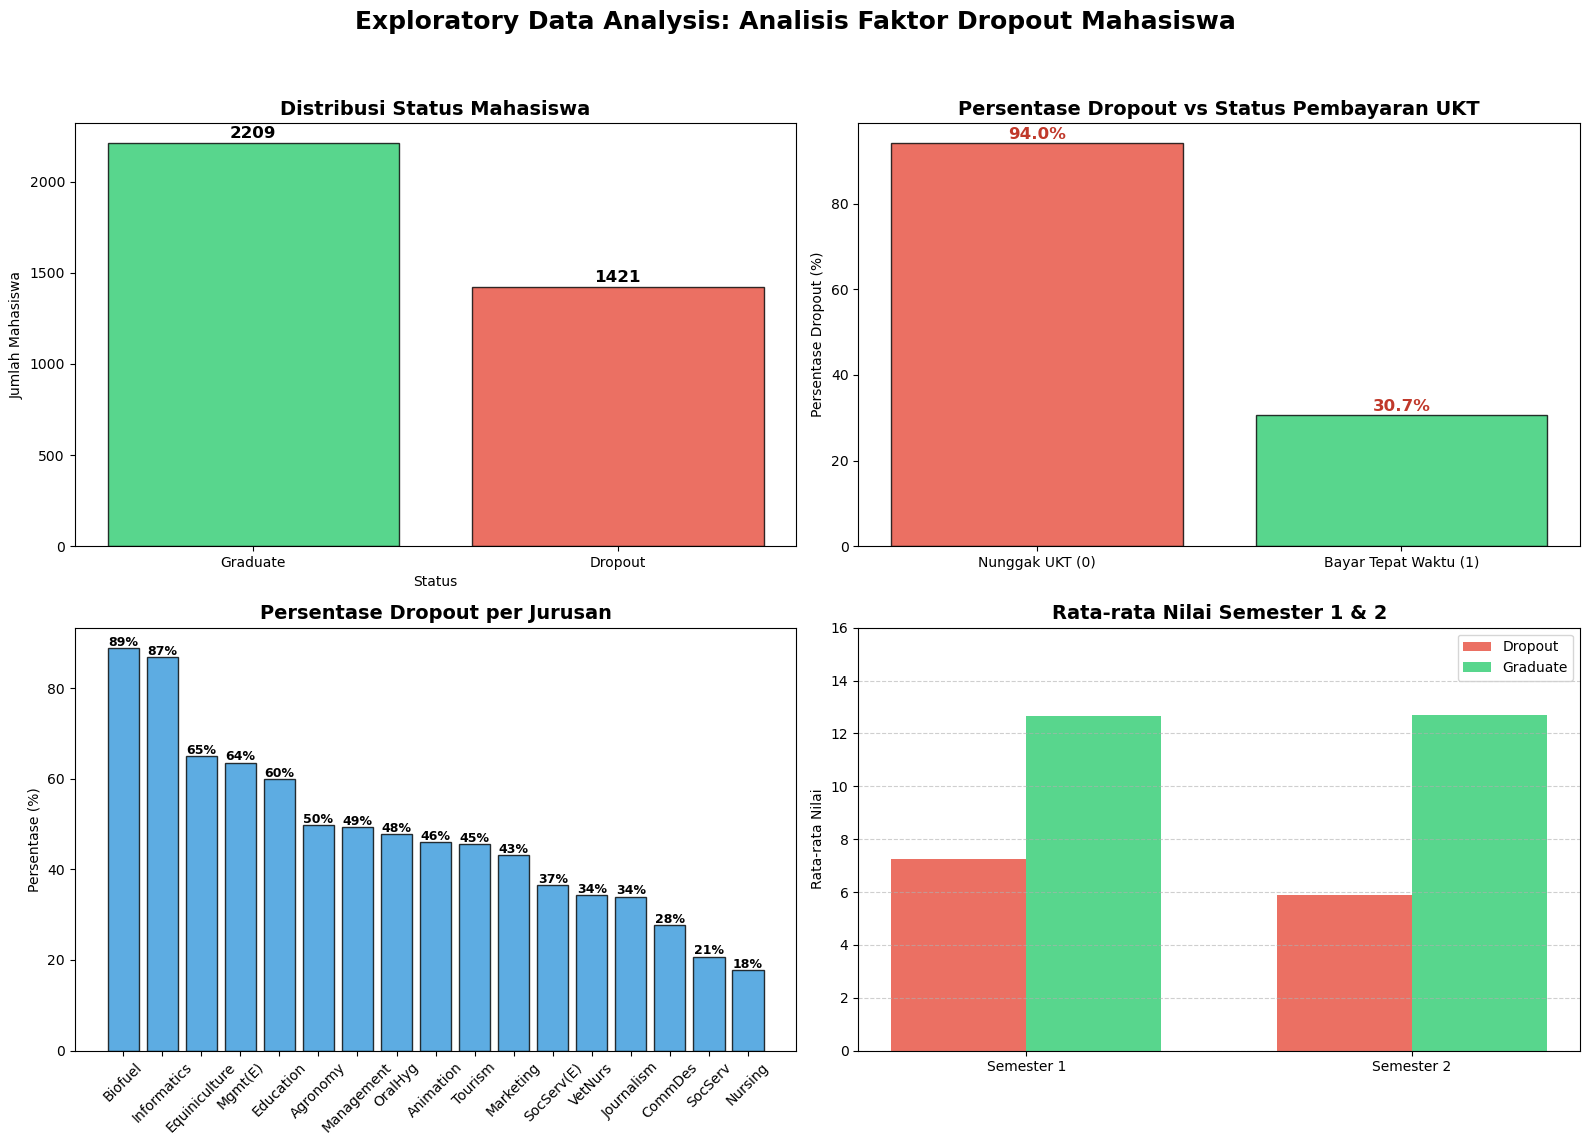

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menyiapkan data mapping untuk jurusan agar tampilan lebih informatif
course_mapping = {
    33: 'Biofuel', 171: 'Animation', 8014: 'SocServ(E)', 9003: 'Agronomy', 
    9070: 'CommDes', 9085: 'VetNurs', 9119: 'Informatics', 9130: 'Equiniculture', 
    9147: 'Management', 9238: 'SocServ', 9254: 'Tourism', 9500: 'Nursing', 
    9556: 'OralHyg', 9670: 'Marketing', 9773: 'Journalism', 9853: 'Education', 
    9991: 'Mgmt(E)'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Exploratory Data Analysis: Analisis Faktor Dropout Mahasiswa", fontsize=18, fontweight="bold")

# 1. Distribusi Kelas
status_counts = df_model["Status"].value_counts()
colors = ["#2ecc71", "#e74c3c"] # Hijau untuk Graduate, Merah untuk Dropout
axes[0, 0].bar(status_counts.index, status_counts.values, color=colors, edgecolor="black", alpha=0.8)
axes[0, 0].set_title("Distribusi Status Mahasiswa", fontsize=14, fontweight="bold")
axes[0, 0].set_xlabel("Status")
axes[0, 0].set_ylabel("Jumlah Mahasiswa")
for i, v in enumerate(status_counts.values):
    axes[0, 0].text(i, v + 30, str(v), ha="center", fontweight="bold", fontsize=12)

# 2. Dropout berdasarkan status pembayaran UKT
# Menghitung persentase dropout per kategori pembayaran
tuition_dropout = df_model.groupby("Tuition_fees_up_to_date")["Status_Dropout"].mean() * 100
axes[0, 1].bar(["Nunggak UKT (0)", "Bayar Tepat Waktu (1)"], tuition_dropout.values, color=["#e74c3c", "#2ecc71"], edgecolor="black", alpha=0.8)
axes[0, 1].set_title("Persentase Dropout vs Status Pembayaran UKT", fontsize=14, fontweight="bold")
axes[0, 1].set_ylabel("Persentase Dropout (%)")
for i, v in enumerate(tuition_dropout.values):
    axes[0, 1].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold", color="#c0392b", fontsize=12)

# 3. Dropout berdasarkan Jurusan
# Persiapan data jurusan
df_temp = df_model.copy()
df_temp['Course_Name'] = df_temp['Course'].map(course_mapping)
course_dropout = df_temp.groupby("Course_Name")["Status_Dropout"].mean().sort_values(ascending=False) * 100
course_dropout.to_csv('dataset_feature_selected.csv', index=False)
# Plotting ke axes[1, 0]
axes[1, 0].bar(course_dropout.index, course_dropout.values, color="#3498db", edgecolor="black", alpha=0.8)
axes[1, 0].set_title("Persentase Dropout per Jurusan", fontsize=14, fontweight="bold")
axes[1, 0].set_ylabel("Persentase (%)")
axes[1, 0].tick_params(axis='x', rotation=45) # Memutar label agar tidak tumpang tindih
for i, v in enumerate(course_dropout.values):
    axes[1, 0].text(i, v + 0.5, f"{v:.0f}%", ha="center", fontsize=9, fontweight="bold")

# 4. Rata-rata nilai Semester 1 & 2
grade_cols = ["Curricular_units_1st_sem_grade", "Curricular_units_2nd_sem_grade"]
grade_by_status = df_model.groupby("Status")[grade_cols].mean()
x = range(len(grade_cols))
width = 0.35

# Plotting bar berdampingan
axes[1, 1].bar([i - width/2 for i in x], grade_by_status.loc["Dropout"], width, label="Dropout", color="#e74c3c", alpha=0.8)
axes[1, 1].bar([i + width/2 for i in x], grade_by_status.loc["Graduate"], width, label="Graduate", color="#2ecc71", alpha=0.8)

axes[1, 1].set_title("Rata-rata Nilai Semester 1 & 2", fontsize=14, fontweight="bold")
axes[1, 1].set_xticks(list(x))
axes[1, 1].set_xticklabels(["Semester 1", "Semester 2"])
axes[1, 1].set_ylabel("Rata-rata Nilai")
axes[1, 1].set_ylim(0, 16) # Memberi ruang untuk legend
axes[1, 1].legend()

# Menambahkan grid untuk mempermudah pembacaan pada grafik nilai
axes[1, 1].yaxis.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Memberi ruang untuk suptitle
plt.show()


## Data Preparation

Tahap **Data Preparation** (Persiapan Data) adalah tahap di mana kita mempersiapkan data agar siap digunakan untuk melatih model machine learning. Tahapan ini meliputi:

1. **Encoding variabel target**: Mengubah label kategorikal menjadi nilai numerik menggunakan LabelEncoder
2. **Pembagian dataset**: Memisahkan dataset menjadi data latih (training) dan data uji (testing)
3. **Penanganan class imbalance dengan SMOTE**: Menggunakan teknik oversampling untuk menyeimbangkan distribusi kelas pada data latih

Persiapan data yang baik sangat krusial untuk menghasilkan model yang akurat dan andal.

### 1. Encoding Variabel Target & Pembagian Dataset

**Encoding Variabel Target:**

Variabel target (`Target`) bersifat kategorikal dengan tiga kelas (Graduate, Dropout, Enrolled). Karena algoritma machine learning bekerja dengan angka, kita perlu mengubahnya menjadi format numerik menggunakan **LabelEncoder**:
- Setiap kategori diberi nilai integer yang unik
- Mapping ini disimpan agar dapat digunakan kembali saat interpretasi hasil prediksi

Selain itu, fitur (X) dipisahkan dari target (y). Kolom `Target` dihapus dari `df_clean` untuk membentuk matriks fitur X.

**Pembagian Data Latih dan Data Uji:**

Dataset dibagi menggunakan `train_test_split` dengan proporsi:
- **80% Data Latih (Training Set)** — Digunakan untuk melatih model
- **20% Data Uji (Testing Set)** — Digunakan untuk mengevaluasi performa model

Parameter `random_state=42` memastikan hasil pembagian yang konsisten dan dapat direproduksi.

In [8]:
# Memisahkan Fitur (X) dan Target (y)
X = df_final.drop(columns=['Status_Dropout'])
y = df_final['Status_Dropout']

# melakukan Label Encoder pada kolom 'Target'
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Membagi data menjadi Train & Test set
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


### 3. Penanganan Class Imbalance dengan SMOTE

**SMOTE (Synthetic Minority Oversampling Technique)** adalah teknik untuk menangani masalah ketidakseimbangan kelas dalam dataset.

**Mengapa SMOTE diperlukan?**
- Ketika distribusi kelas tidak seimbang, model machine learning cenderung bias terhadap kelas mayoritas
- Model mungkin memiliki akurasi tinggi secara keseluruhan tetapi buruk dalam mendeteksi kelas minoritas (misalnya, Dropout)

**Cara kerja SMOTE:**
- SMOTE membuat sampel sintetis baru untuk kelas minoritas
- Sampel baru dibuat dengan interpolasi antara sampel yang sudah ada
- Hasilnya adalah distribusi kelas yang lebih seimbang pada data latih

**Catatan penting:** SMOTE hanya diterapkan pada **data latih**, bukan data uji. Ini penting agar evaluasi model dilakukan pada data dengan distribusi asli yang dapat mencerminkan kondisi sebenarnya.

In [9]:
# Inisialisasi SMOTE
smote = SMOTE(random_state=42, sampling_strategy='auto')
# Menerapkan SMOTE
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
# Mengecek distribusi kelas setelah SMOTE

print("Jumlah data per kelas sebelum SMOTE:")
print(pd.Series(y_train).value_counts())
print("\nJumlah data per kelas setelah SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Jumlah data per kelas sebelum SMOTE:
0    1760
1    1144
Name: count, dtype: int64

Jumlah data per kelas setelah SMOTE:
1    1760
0    1760
Name: count, dtype: int64


## Modeling

Tahap **Modeling** adalah proses pembuatan dan pelatihan model machine learning menggunakan data yang telah dipersiapkan. Dalam proyek ini, kita menggunakan dua algoritma berbasis ensemble:

### 1. Random Forest Classifier
Random Forest adalah algoritma ensemble yang membangun banyak decision tree secara paralel dan menggabungkan hasilnya:
- **n_estimators=100**: Menggunakan 100 pohon keputusan
- **random_state=42**: Untuk reproducibility

**Keunggulan**: Robust terhadap overfitting, dapat menangani fitur yang banyak, memberikan feature importance

### 2. Gradient Boosting Classifier
Gradient Boosting adalah algoritma ensemble yang membangun model secara sekuensial, di mana setiap model baru berusaha memperbaiki kesalahan model sebelumnya:
- **n_estimators=100**: Menggunakan 100 estimator
- **learning_rate=0.1**: Laju pembelajaran untuk mengontrol kontribusi setiap pohon
- **max_depth=3**: Kedalaman maksimum setiap pohon
- **random_state=42**: Untuk reproducibility

**Keunggulan**: Sering menghasilkan prediksi yang lebih akurat, bekerja baik pada berbagai jenis data

Kedua model akan dilatih menggunakan data yang telah di-oversampling dengan SMOTE (`X_train_resampled`, `y_train_resampled`).

In [10]:
# Inisialisasi model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Melatih model dengan data yang sudah di-SMOTE
rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

In [11]:
# Inisialisasi model Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Melatih model dengan data yang sudah di-SMOTE
gb_model.fit(X_train_resampled, y_train_resampled)

GradientBoostingClassifier(random_state=42)

## Evaluation

Tahap **Evaluation** adalah proses menilai performa model machine learning yang telah dilatih menggunakan data uji (test set). Evaluasi dilakukan untuk memahami seberapa baik model dapat memprediksi data baru yang belum pernah dilihat sebelumnya.

### Metrik Evaluasi yang Digunakan:

1. **Accuracy (Akurasi)**: Proporsi prediksi yang benar dari total prediksi
   - Formula: (TP + TN) / (TP + TN + FP + FN)

2. **Precision**: Dari semua yang diprediksi sebagai positif, berapa yang benar-benar positif
   - Formula: TP / (TP + FP)

3. **Recall**: Dari semua yang sebenarnya positif, berapa yang berhasil dideteksi
   - Formula: TP / (TP + FN)

4. **F1-Score**: Rata-rata harmonik dari precision dan recall
   - Formula: 2 × (Precision × Recall) / (Precision + Recall)

### Evaluasi Kedua Model:
Kita akan membandingkan performa Random Forest dan Gradient Boosting untuk menentukan model terbaik yang akan digunakan dalam deployment.

**Catatan:**
- Kelas `0`: Dropout
- Kelas `1`: Graduate

In [12]:
# Prediksi dan Evaluasi
y_pred_rf = rf_model.predict(X_test)
print("=== Random Forest Classifier ===")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred_rf))

=== Random Forest Classifier ===

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       449
           1       0.87      0.84      0.85       277

    accuracy                           0.89       726
   macro avg       0.88      0.88      0.88       726
weighted avg       0.89      0.89      0.89       726



In [13]:
# Prediksi dan Evaluasi
y_pred_gb = gb_model.predict(X_test)
print("=== Gradient Boosting Classifier ===")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred_gb))

=== Gradient Boosting Classifier ===

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       449
           1       0.88      0.84      0.86       277

    accuracy                           0.89       726
   macro avg       0.89      0.88      0.89       726
weighted avg       0.89      0.89      0.89       726



In [14]:
models = {
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

eval_data = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    eval_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted')
    })

df_evaluasi = pd.DataFrame(eval_data)
df_evaluasi = df_evaluasi.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print(df_evaluasi)

               Model  Accuracy  Precision    Recall  F1-Score
0  Gradient Boosting  0.893939   0.893513  0.893939  0.893422
1      Random Forest  0.888430   0.887983  0.888430  0.888062


## Deployment

Tahap **Deployment** adalah proses menyimpan model yang telah dilatih agar dapat digunakan dalam lingkungan produksi atau aplikasi nyata.

### Menggunakan joblib:
**joblib** adalah library yang efisien untuk serialisasi objek Python, terutama untuk array NumPy dan model scikit-learn.

Model **Gradient Boosting Classifier** (`gb_model`) dipilih untuk disimpan karena:
- Memiliki performa (F1-Score) yang lebih tinggi dibandingkan Random Forest
- Cocok untuk digunakan dalam sistem prediksi real-time

File model disimpan sebagai `model_do_prediction.pkl` yang kemudian dapat digunakan dalam aplikasi prediksi mahasiswa dropout.

In [15]:
# Simpan Model (Deployment readiness)
joblib.dump(gb_model, 'model_do_prediction.pkl')

['model_do_prediction.pkl']

## Kesimpulan & Rekomendasi

### Kesimpulan

Berdasarkan analisis data dan pemodelan yang telah dilakukan, ditemukan beberapa faktor utama yang mempengaruhi tingginya tingkat *dropout* mahasiswa:

1. **Kinerja Akademis**: Mahasiswa yang memiliki jumlah mata kuliah yang lulus (*approved units*) dan nilai (*grade*) yang rendah pada Semester 1 dan Semester 2 memiliki kecenderungan sangat tinggi untuk *dropout*.

2. **Faktor Finansial**: Mahasiswa yang menunggak pembayaran uang kuliah (`Tuition_fees_up_to_date = 0`) memiliki persentase *dropout* yang jauh lebih tinggi dibandingkan mahasiswa yang membayar tepat waktu.

3. **Usia saat Mendaftar**: Mahasiswa yang mendaftar pada usia yang lebih tua menunjukkan risiko *dropout* yang lebih tinggi, kemungkinan karena beban ganda dengan pekerjaan atau tanggung jawab keluarga.

Model **Gradient Boosting** dipilih sebagai model final karena menghasilkan performa yang lebih baik dibandingkan Random Forest pada data uji ini.

### Rekomendasi Action Items

1. **Sistem Peringatan Dini (*Early Warning System*)**: Pantau ketat mahasiswa yang memiliki tingkat kelulusan mata kuliah dan nilai yang rendah di akhir Semester 1. Segera panggil mereka untuk sesi konseling akademik.

2. **Keringanan/Restrukturisasi Pembayaran UKT**: Proaktif menawarkan skema cicilan atau bantuan finansial/beasiswa bagi mahasiswa yang mulai menunggak biaya kuliah sebelum mereka memutuskan untuk *dropout*.

3. **Program Mentorship Tahun Pertama**: Mengingat performa di dua semester awal sangat krusial, bentuk program *mentoring* di mana mahasiswa tingkat akhir membimbing mahasiswa baru agar lebih adaptif terhadap kehidupan kampus.